# NUTDTS 816 Time Series Analysis
## L01 Introduction to time series data

Lab notebook for Chapter 1 of the lecture notes. Run the setup cell first. Every code cell reproduces an example from the notes; the exercises at the end are from the chapter's self-check list.

**Instructor:** Dr Tolulope Adesina · NUTM MSc Data Science · 2026

In [1]:
# ---- Setup: run once per Colab session ----
# 1. Install the course libraries (about two minutes the first time)
!pip install -q statsmodels pmdarima statsforecast neuralforecast lightgbm arch plotly

# 2. Fetch the course data module and data snapshots from the course repository.
#    Replace REPO with your fork if you do not want to work from the official course repository URL.
REPO = "https://github.com/PreciousFaseyosan/NUTDTS816-Time_Series_Analysis-_Course_Repository/raw/main"
import urllib.request, os
os.makedirs("data", exist_ok=True)
urllib.request.urlretrieve(f"{REPO}/src/tsdata.py", "tsdata.py")
DATA_FILES = ["nigeria_cpi", "nigeria_fx", "nigeria_grid", "nigeria_malaria", "nigeria_rainfall", "bonny_light", "daily_demand",
              "airpassengers", "a10", "h02", "ausbeer", "elecequip", "usmelec", "goog", "nile", "austourists", "oil", "dax", "uschange", "elecdemand"]
for f in DATA_FILES:
    urllib.request.urlretrieve(f"{REPO}/data/{f}.csv", f"data/{f}.csv")

import warnings; warnings.filterwarnings("ignore")
import pandas as pd, numpy as np, matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9, 3.6), "axes.grid": True, "grid.alpha": 0.3, "axes.spines.top": False, "axes.spines.right": False})
import tsdata
print("Setup complete.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 501.8/501.8 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 982.9/982.9 kB 51.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.7/348.7 kB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.0/281.0 kB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 831.6/831.6 kB 51.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.3/78.3 MB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

### 1.6 Working with time series in pandas

In [2]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import tsdata   # course data module (real fpp2/R datasets; simulated Nigerian-shaped series)

ap = tsdata.airpassengers()      # monthly international airline passengers, 1949-1960 (thousands)
print(type(ap), ap.index.freq)
print(ap.head(6))
print(ap.index[:3])

<class 'pandas.core.series.Series'> <MonthBegin>
date
1949-01-01    112
1949-02-01    118
1949-03-01    132
1949-04-01    129
1949-05-01    121
1949-06-01    135
Freq: MS, Name: passengers, dtype: int64
DatetimeIndex(['1949-01-01', '1949-02-01', '1949-03-01'], dtype='datetime64[ns]', name='date', freq='MS')


In [3]:
# A messy extract, as you might receive it from a portal
raw = pd.DataFrame({
    'period': ['2024-01', '2024-02', '2024-03', '2024-05', '2024-05', '2024-06', '2024-08'],
    'cpi':    [  743.1,    752.6,    766.0,     787.9,     787.9,    803.4,     828.7]})
raw['date'] = pd.to_datetime(raw['period'], format='%Y-%m')
s = raw.drop_duplicates('date').set_index('date')['cpi']
s = s.asfreq('MS')                       # impose a regular monthly grid; gaps become NaN
print(s)
print('missing:', s.isna().sum())

date
2024-01-01    743.1
2024-02-01    752.6
2024-03-01    766.0
2024-04-01      NaN
2024-05-01    787.9
2024-06-01    803.4
2024-07-01      NaN
2024-08-01    828.7
Freq: MS, Name: cpi, dtype: float64
missing: 2


In [4]:
s_filled = s.interpolate(method='linear')   # simple, defensible for a smooth monthly index
print(s_filled.round(1))

date
2024-01-01    743.1
2024-02-01    752.6
2024-03-01    766.0
2024-04-01    777.0
2024-05-01    787.9
2024-06-01    803.4
2024-07-01    816.0
2024-08-01    828.7
Freq: MS, Name: cpi, dtype: float64


In [5]:
dem = tsdata.elecdemand()    # half-hourly electricity demand, Victoria (Australia), 2014
print(dem.head(3))
daily = dem['Demand'].resample('D').sum()          # daily total demand (GW-halfhours)
monthly_mean = dem['Demand'].resample('MS').mean() # monthly mean half-hourly demand
print(daily.head(3).round(1)); print(monthly_mean.round(2).head(3))

                       Demand  WorkDay  Temperature
date                                               
2014-01-01 00:00:00  3.914647        0         18.2
2014-01-01 00:30:00  3.672550        0         17.9
2014-01-01 01:00:00  3.497539        0         17.6
date
2014-01-01    174.9
2014-01-02    188.6
2014-01-03    188.9
Freq: D, Name: Demand, dtype: float64
date
2014-01-01    4.83
2014-02-01    4.82
2014-03-01    4.40
Freq: MS, Name: Demand, dtype: float64


In [6]:
cpi  = tsdata.nigeria_cpi()     # monthly CPI, Jan 2015 - Jun 2026 (simulated)
fx   = tsdata.nigeria_fx()      # monthly NGN/USD, Jan 2015 - Jun 2026 (simulated)
grid = tsdata.nigeria_grid()    # monthly average grid generation, MW (simulated)
print(pd.concat([cpi, fx, grid], axis=1).tail(4))

            cpi    ngn_usd  generation_mw
date                                     
2026-04-01  NaN  1360.7185         3500.0
2026-05-01  NaN  1369.4947            NaN
2026-06-01  NaN  1366.4902            NaN
2026-07-01  NaN  1372.7523            NaN


## Exercises

1. For each of the following, state the natural frequency, the seasonal period(s) $m$, and whether you expect the series to be additive or multiplicative: hourly grid frequency; monthly rice prices in Lagos; quarterly Nigerian GDP; daily visits to a hospital emergency department; weekly cholera cases.
2. The `a10` series in the course data module is monthly antidiabetic drug sales in Australia. Produce the time plot, the log time plot, a seasonal plot and the ACF of the first difference of the log. Describe the trend, the seasonality and its type. What happens every January, and why might that be?
3. Simulate a random walk $x_t = x_{t-1} + \varepsilon_t$ with $\varepsilon_t \sim N(0,1)$ for $T = 200$ and plot its ACF. Explain why the ACF looks like that of a trending series even though the process has no deterministic trend.

## Solutions to Exercises

**Question 1**

**Hourly Grid Frequency**
nf = Daily
m = 24
Test: grid frequency oscillates in small deviations around a fixed reference (50 Hz). The size of the deviation doesn't scale with the level, it's just noise around a constant.
→ Series would be additive.

**Monthly Rice Prices in Lagos**
nf = Annually
m = 12
Test: in a growing, inflationary economy, a seasonal price effect (e.g. a wet-season transport-cost bump) is more likely to scale proportionally with the current price level than stay a fixed ₦ amount.
→ Series would be multiplicative.

**Quarterly Nigerian GDP**
nf = Annual
m = 4
Test: GDP grows substantially over time, and quarterly effects (Q4 festive spending, oil production cycles) scale with the size of the economy rather than staying a fixed ₦/$ amount.
→ Series would be multiplicative.

**Daily visits to a hospital emergency room**
nf = Weekly or Annually
m = 7 or 365.25 (two periods can stack at once — a weekday/weekend pattern and a flu-season-type annual pattern)
Test: without a strong long-run growth trend in visit counts, the seasonal swing is more plausibly a roughly fixed number of extra visits rather than one that scales with the overall level.
→ Series would be additive.

**Weekly Cholera Cases**
nf = Annually
m = 52.18
Test: outbreak-driven disease counts tend to grow proportionally once an epidemic takes hold (epidemic spread is multiplicative in nature, not additive) though this depends on whether the series shows real growth or stays around a stable baseline.
→ Series would be multiplicative.

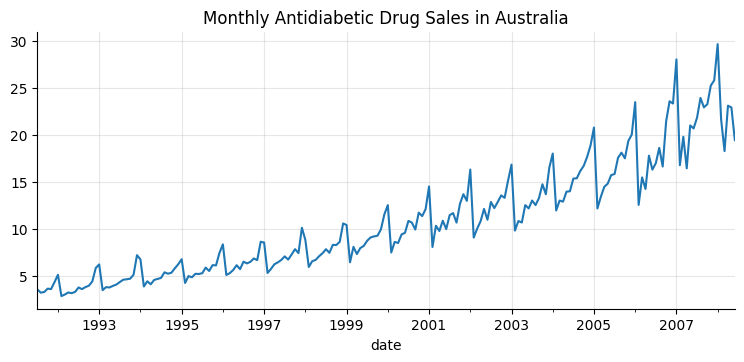

In [16]:
# Question 2 - time plot
a10 = tsdata.a10()
ax = a10.plot(title='Monthly Antidiabetic Drug Sales in Australia')

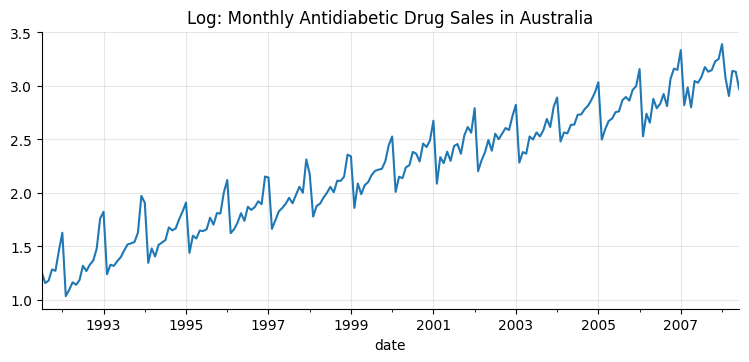

In [17]:
# Question 2 - log plot
a10 = tsdata.a10()
ax = np.log(a10).plot(title='Log: Monthly Antidiabetic Drug Sales in Australia')

<Axes: title={'center': 'Seasonal plot: Monthly Antidiabetic Drug Sale, one line per year (dark = early, light = late)'}, xlabel='Month'>

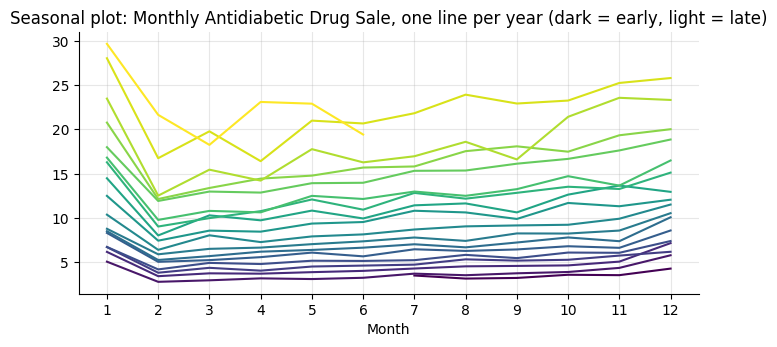

In [20]:
# Question 2 - seasonal plot
def seasonal_plot(s, period_label='year', title=''):
    df = pd.DataFrame({'v': s.values, 'year': s.index.year, 'month': s.index.month})
    piv = df.pivot(index='month', columns='year', values='v')
    ax = piv.plot(legend=False, colormap='viridis', title=title, figsize=(8, 3.4))
    ax.set_xlabel('Month'); ax.set_xticks(range(1, 13))
    for col in piv.columns[-1:]: ax.annotate(str(col), (12, piv[col].iloc[-1]), fontsize=8)
    return ax

seasonal_plot(a10, title='Seasonal plot: Monthly Antidiabetic Drug Sale, one line per year (dark = early, light = late)')

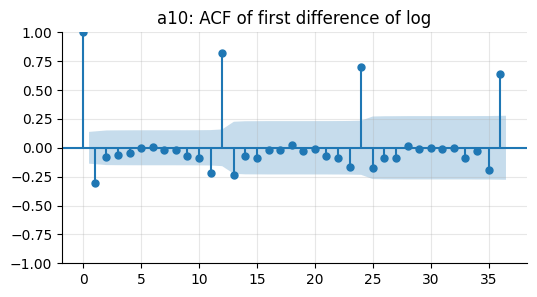

In [24]:
# Question 2 - ACF of first difference of log(a10)
from statsmodels.graphics.tsaplots import plot_acf
fig, ax = plt.subplots(figsize=(6, 3))
plot_acf(np.log(a10).diff().dropna(), lags=36, ax=ax, title='a10: ACF of first difference of log')
plt.show()

### Question 2: Trend, Seasonality and its type, what happens every January

**Trend:** Upward Trend

**Seasonality and type:** Seasonality is multiplicative. The seasonal wings widen as the trend increases. Sales increase every November to January.

**What happens every January:** Drug Sales skyrocket. This is likely due to Australia's PBS subsidy safety-net threshold resetting in January.

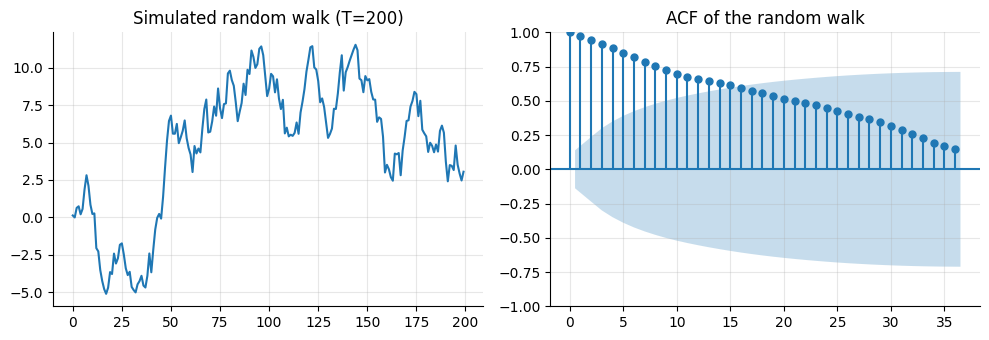

In [25]:
# Question 3

rng = np.random.default_rng(0)          # seeded, so your result is reproducible
eps = rng.normal(loc=0, scale=1, size=200)   # 200 draws of ε_t ~ N(0,1)
x = eps.cumsum()                         # x_t = x_1 + x_2 + ... running total
rw = pd.Series(x, name='random_walk')

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
rw.plot(ax=axes[0], title='Simulated random walk (T=200)')
plot_acf(rw, lags=36, ax=axes[1], title='ACF of the random walk')
plt.tight_layout()
plt.show()

The simulated random walk shows an ACF that starts close to 1 and declines slowly as the lag increases. This happens because a random walk accumulates past shocks, so observations close together share most of the same historical shocks, while observations farther apart still share part of that history. As a result, the observations remain highly correlated across many lags, producing a slowly declining ACF that resembles the ACF of a trending series, even though the process has **no deterministic trend**: its apparent movement comes entirely from the accumulation of random shocks. This similarity is important because the ACF alone cannot distinguish a deterministic trend from a random walk. The two also require different treatments: a deterministic trend should be **removed by detrending**, while a random walk should be **made stationary by first differencing**. Using the wrong treatment can cause problems; for example, detrending a random walk may leave it non-stationary, while unnecessarily differencing a deterministic trend can introduce unwanted structure. Therefore, tests such as **ADF and KPSS**, along with plots and domain knowledge, can help determine the appropriate treatment.
